# Matmul, rearranged
One multiplication, many ways to walk through it. We start from the loop you already know and get every other form by **moving loops around**. Nothing new is ever added: the same 64 multiplies, in a different order, with the unfinished sums kept in different places.

How to read this notebook: grey boxes are Python you can run. Their output prints every step in text. The white boxes are animations of the same thing: press **Step**, or click the box and use the arrow keys (→ step, ↓ whole inner loop, P play).

In [1]:
import numpy as np

# The running example: small whole numbers so every step can be checked by hand.
A = [[1, 2, 0, 3],
     [0, 1, 2, 1],
     [3, 0, 1, 2],
     [2, 1, 3, 0]]
B = [[2, 0, 1, 3],
     [1, 3, 0, 2],
     [0, 1, 2, 1],
     [3, 2, 1, 0]]
M, K = 4, 4          # A is M x K
N = 4                # B is K x N, so C is M x N
REF = (np.array(A) @ np.array(B)).tolist()   # the answer every form must reach

def show(name, X):
    print(f"{name} =")
    for row in X:
        print("   ", " ".join(f"{v:3d}" for v in row))

show("A", A)
show("B", B)
print("C = ?  (4 x 4, one value per (i, j), each value is a sum of K = 4 products)")

A =
      1   2   0   3
      0   1   2   1
      3   0   1   2
      2   1   3   0
B =
      2   0   1   3
      1   3   0   2
      0   1   2   1
      3   2   1   0
C = ?  (4 x 4, one value per (i, j), each value is a sum of K = 4 products)


## The names we use everywhere
<span style="color:#2360c8;font-weight:600">A</span>[M, K] @ <span style="color:#d9730a;font-weight:600">B</span>[K, N] → <span style="color:#148552;font-weight:600">C</span>[M, N]

- **i** walks over M: the rows of <span style="color:#2360c8;font-weight:600">A</span> and of <span style="color:#148552;font-weight:600">C</span>
- **j** walks over N: the columns of <span style="color:#d9730a;font-weight:600">B</span> and of <span style="color:#148552;font-weight:600">C</span>
- **k** walks over K: the columns of <span style="color:#2360c8;font-weight:600">A</span> = the rows of <span style="color:#d9730a;font-weight:600">B</span>. <span style="color:#148552;font-weight:600">C</span> has no k: k is the index that gets *summed away*.

One elementary step is always the same line: `C[i][j] += A[i][k] * B[k][j]`

Colours never change: <span style="color:#2360c8;font-weight:600">A</span> is blue, <span style="color:#d9730a;font-weight:600">B</span> is orange, <span style="color:#148552;font-weight:600">C</span> is green. A pale green <span style="color:#148552;font-weight:600">C</span> value is unfinished (it has only some of its 4 terms). A solid green one is finished.

In [2]:
class Tracker:
    """Holds C, how many of its K terms each C value has received so far, and honest counters.
    The FIRST term of a C value is just stored (no addition), so a full 4x4 product costs
    64 multiplies and 48 additions, whatever the loop order."""
    def __init__(self):
        self.C = [[0] * N for _ in range(M)]
        self.terms = [[0] * N for _ in range(M)]
        self.mults = self.adds = self.steps = 0

    def step(self, i, j, k, say=False):
        a, b = A[i][k], B[k][j]
        p, old, first = a * b, self.C[i][j], self.terms[i][j] == 0
        if not first:
            self.adds += 1
        self.C[i][j] = old + p
        self.terms[i][j] += 1
        self.mults += 1
        self.steps += 1
        if say:
            t = self.terms[i][j]
            math = f"= {p} (first term, just stored)" if first else f"= {old} + {p} = {old + p}"
            state = "FINISHED" if t == K else "partial"
            print(f"step {self.steps:2d}: C[{i}][{j}] += A[{i}][{k}]*B[{k}][{j}] = {a}*{b} = {p}"
                  f"  ->  C[{i}][{j}] {math}   (term {t}/{K}, {state})")

    def partial(self):
        return sum(1 for row in self.terms for t in row if 0 < t < K)

    def finished(self):
        return sum(1 for row in self.terms for t in row if t == K)

    def picture(self, label="C"):
        """13* = finished value, 5~ = partial value, . = nothing yet"""
        print(f"{label}   (* finished, ~ partial, . empty)")
        for i in range(M):
            cells = []
            for j in range(N):
                t = self.terms[i][j]
                cells.append("   ." if t == 0 else f"{self.C[i][j]:3d}{'*' if t == K else '~'}")
            print("   ", " ".join(cells))

    def check(self):
        ok = self.C == REF
        print(f"multiplies = {self.mults}, additions = {self.adds}, partial = {self.partial()}, "
              f"C == A @ B ? {ok}")
        return ok

print("Tracker ready.")

Tracker ready.


## 1 · The loop you already know
For each row i and each column j, walk along k and add up the products. The running sum lives in one place (one register) until it is done, then it is written into <span style="color:#148552;font-weight:600">C</span>[i][j] and never touched again.

In [3]:
C = [[0] * N for _ in range(M)]
mults = adds = 0
for i in range(M):
    for j in range(N):
        acc = 0                                   # one register
        for k in range(K):
            acc += A[i][k] * B[k][j]
            mults += 1
            adds += 1 if k > 0 else 0             # first term: just stored
        C[i][j] = acc                             # written once, finished
        terms = " + ".join(f"{A[i][k]}*{B[k][j]}" for k in range(K))
        print(f"C[{i}][{j}] = {terms} = {acc}")
show("C", C)
print(f"multiplies = {mults}, additions = {adds}, C == A @ B ? {C == REF}")

C[0][0] = 1*2 + 2*1 + 0*0 + 3*3 = 13
C[0][1] = 1*0 + 2*3 + 0*1 + 3*2 = 12
C[0][2] = 1*1 + 2*0 + 0*2 + 3*1 = 4
C[0][3] = 1*3 + 2*2 + 0*1 + 3*0 = 7
C[1][0] = 0*2 + 1*1 + 2*0 + 1*3 = 4
C[1][1] = 0*0 + 1*3 + 2*1 + 1*2 = 7
C[1][2] = 0*1 + 1*0 + 2*2 + 1*1 = 5
C[1][3] = 0*3 + 1*2 + 2*1 + 1*0 = 4
C[2][0] = 3*2 + 0*1 + 1*0 + 2*3 = 12
C[2][1] = 3*0 + 0*3 + 1*1 + 2*2 = 5
C[2][2] = 3*1 + 0*0 + 1*2 + 2*1 = 7
C[2][3] = 3*3 + 0*2 + 1*1 + 2*0 = 10
C[3][0] = 2*2 + 1*1 + 3*0 + 0*3 = 5
C[3][1] = 2*0 + 1*3 + 3*1 + 0*2 = 6
C[3][2] = 2*1 + 1*0 + 3*2 + 0*1 = 8
C[3][3] = 2*3 + 1*2 + 3*1 + 0*0 = 11
C =
     13  12   4   7
      4   7   5   4
     12   5   7  10
      5   6   8  11
multiplies = 64, additions = 48, C == A @ B ? True


**What to notice.** Each <span style="color:#148552;font-weight:600">C</span> value is started, finished, and never visited again. During the whole k loop, the thing that does not move is <span style="color:#148552;font-weight:600">C</span>[i][j]: it sits in one register while <span style="color:#2360c8;font-weight:600">A</span> and <span style="color:#d9730a;font-weight:600">B</span> values stream past.

The textbook name for "one dot product per <span style="color:#148552;font-weight:600">C</span> value" is the **inner-product form**. Hardware people name a loop after the operand that stays put. Here <span style="color:#148552;font-weight:600">C</span>, the output, stays put, so this is **output-stationary** (**os**).

In [4]:
# Pictures for Jupyter (the HTML page shows the same thing animated).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BLUE, ORANGE, GREEN, PALE = "#2360c8", "#d9730a", "#148552", "#c9ecd8"
STAYS = {"k": "C", "i": "B", "j": "A"}

def frames(order, bs=1):
    n = 4 // bs
    out = []
    x, y, z = order
    for a in range(n):
        for b in range(n):
            for c in range(n):
                idx = {x: a, y: b, z: c}
                out.append([(idx["i"]*bs + ii, idx["j"]*bs + jj, idx["k"]*bs + kk)
                            for ii in range(bs) for jj in range(bs) for kk in range(bs)])
    return out

def draw(order, t, bs=1, ax=None):
    tr, last = Tracker(), []
    for ops in frames(order, bs)[:t]:
        last = ops
        for (i, j, k) in ops:
            tr.step(i, j, k)
    ax = ax or plt.gca()
    stay = STAYS[order[2]]
    def box(x, y, fill, text, edge="none", lw=0):
        ax.add_patch(Rectangle((x, y), 0.92, 0.92, facecolor=fill, edgecolor=edge, linewidth=lw))
        ax.text(x + 0.46, y + 0.46, text, ha="center", va="center", fontsize=9, family="monospace",
                color="white" if fill in (BLUE, ORANGE, GREEN) else "black")
    readA = {(i, k) for i, j, k in last}; readB = {(k, j) for i, j, k in last}; wr = {(i, j) for i, j, k in last}
    sA = {(i, k) for i, j, k in last} if stay == "A" else set()
    sB = {(k, j) for i, j, k in last} if stay == "B" else set()
    sC = wr if stay == "C" else set()
    for r in range(4):
        for c in range(4):
            box(c, -r, BLUE if (r, c) in readA else "#dbe6f7", A[r][c], BLUE, 3 if (r, c) in sA else 0)
            box(5 + c, 5 - r, ORANGE if (r, c) in readB else "#f8e3cc", B[r][c], ORANGE, 3 if (r, c) in sB else 0)
            tt = tr.terms[r][c]
            fill = GREEN if tt == K else PALE if tt else "#f2f2f2"
            box(5 + c, -r, fill, tr.C[r][c] if tt else "·", GREEN if (r, c) in sC else "black",
                3 if (r, c) in sC else (1.2 if (r, c) in wr else 0))
    ax.text(1.9, 1.4, "A", color=BLUE, fontsize=14, weight="bold")
    ax.text(6.9, 6.4, "B", color=ORANGE, fontsize=14, weight="bold")
    ax.text(9.3, -1.6, "C", color=GREEN, fontsize=14, weight="bold")
    ax.set_xlim(-0.3, 9.6); ax.set_ylim(-3.4, 7); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{order}, after {t} step(s)", fontsize=10)

def snapshots(order, steps, bs=1):
    fig, axes = plt.subplots(1, len(steps), figsize=(3.2 * len(steps), 3.3))
    for ax, t in zip(np.atleast_1d(axes), steps):
        draw(order, t, bs, ax)
    plt.tight_layout(); plt.show()

print("Drawing helpers ready.")

Drawing helpers ready.


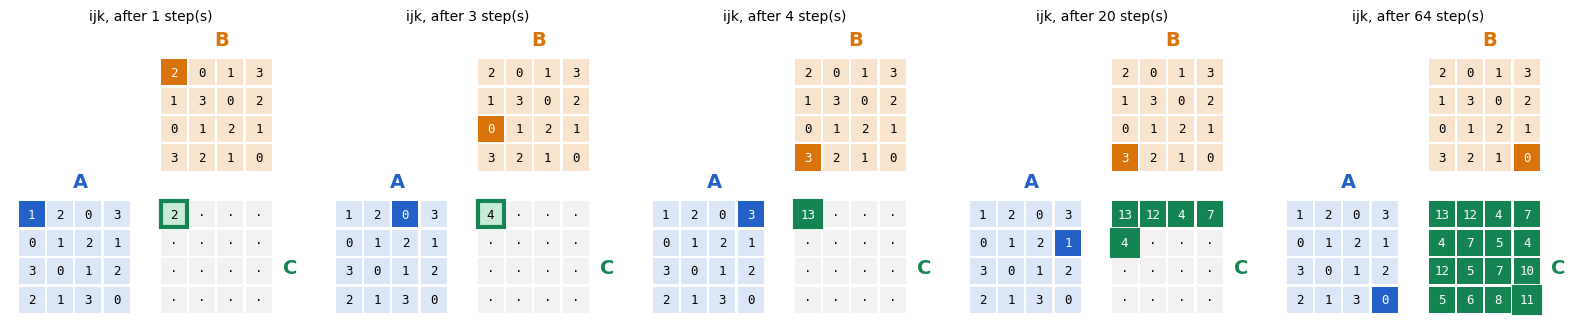

In [5]:
snapshots('ijk', [1, 3, 4, 20, 64])

## 2 · The one rule behind every name
Each operand uses two of the three indices: <span style="color:#2360c8;font-weight:600">A</span>[i][k], <span style="color:#d9730a;font-weight:600">B</span>[k][j], <span style="color:#148552;font-weight:600">C</span>[i][j]. The innermost loop changes one index every step. Two operands contain that index, so they change. The third one does not contain it, so it **stays put**.

| innermost loop | changes every step | stays put | name |
|---|---|---|---|
| k | <span style="color:#2360c8;font-weight:600">A</span>[i][k] and <span style="color:#d9730a;font-weight:600">B</span>[k][j] | <span style="color:#148552;font-weight:600">C</span>[i][j] | **output-stationary (os)** |
| i | <span style="color:#2360c8;font-weight:600">A</span>[i][k] and <span style="color:#148552;font-weight:600">C</span>[i][j] | <span style="color:#d9730a;font-weight:600">B</span>[k][j] | **weight-stationary (ws)** |
| j | <span style="color:#d9730a;font-weight:600">B</span>[k][j] and <span style="color:#148552;font-weight:600">C</span>[i][j] | <span style="color:#2360c8;font-weight:600">A</span>[i][k] | **input-stationary (is)** |

("Weight" because in neural networks <span style="color:#d9730a;font-weight:600">B</span> usually holds the trained weights; "input" because <span style="color:#2360c8;font-weight:600">A</span> holds the activations coming in.)

In [6]:
INDICES = {"A": "ik", "B": "kj", "C": "ij"}
def stays_put(order):
    inner = order[-1]
    return [name for name, idx in INDICES.items() if inner not in idx][0]

for order in ["ijk", "jki", "ikj"]:
    s = stays_put(order)
    moving = [n for n in "ABC" if n != s]
    print(f"loops {order}: innermost {order[-1]} -> {moving[0]} and {moving[1]} change, {s} stays put")

loops ijk: innermost k -> A and B change, C stays put
loops jki: innermost i -> A and C change, B stays put
loops ikj: innermost j -> B and C change, A stays put


The same 4×4 product in the three styles, stepping together. Watch the glowing cell: it is the operand that stays put during the inner loop.

## 3 · All six loop orders
Three loops can be nested in 3 × 2 × 1 = 6 orders. The line inside never changes. The rule tells us what stays put; the classic textbook name tells us what one pass of the inner loop builds.

| order | innermost | stays put | classic name | one inner loop builds… |
|---|---|---|---|---|
| ijk, jik | k | <span style="color:#148552;font-weight:600">C</span>[i][j] | **inner product** (os) | one finished <span style="color:#148552;font-weight:600">C</span> value (a dot product) |
| ikj | j | <span style="color:#2360c8;font-weight:600">A</span>[i][k] | **row-wise** / Gustavson (is) | `C[i,:] += A[i][k] * B[k,:]`: a whole row of <span style="color:#148552;font-weight:600">C</span>, partially |
| jki | i | <span style="color:#d9730a;font-weight:600">B</span>[k][j] | **column-wise** (ws) | `C[:,j] += A[:,k] * B[k][j]`: a whole column of <span style="color:#148552;font-weight:600">C</span>, partially |
| kij | j | <span style="color:#2360c8;font-weight:600">A</span>[i][k] | **outer product** (is inside) | one row of the update `A[:,k] ⊗ B[k,:]` |
| kji | i | <span style="color:#d9730a;font-weight:600">B</span>[k][j] | **outer product** (ws inside) | one column of the same update |

For the outer-product forms, the two inner loops together add a whole 4×4 **rank-1 update** (column k of <span style="color:#2360c8;font-weight:600">A</span> times row k of <span style="color:#d9730a;font-weight:600">B</span>) into <span style="color:#148552;font-weight:600">C</span>: one update per k.

In [7]:
STAYS = {"k": "C", "i": "B", "j": "A"}
NAMES = {"C": "output-stationary (os)", "B": "weight-stationary (ws)", "A": "input-stationary (is)"}
FORM = {"ijk": "inner product", "jik": "inner product", "ikj": "row-wise (Gustavson)",
        "jki": "column-wise", "kij": "outer product", "kji": "outer product"}

def run(order, say=False, limit=None):
    """Run the three loops in the given order. say=True prints each step (up to `limit`)."""
    tr = Tracker()
    ranges = {"i": range(M), "j": range(N), "k": range(K)}
    x, y, z = order
    for a in ranges[x]:
        for b in ranges[y]:
            for c in ranges[z]:
                idx = {x: a, y: b, z: c}
                tr.step(idx["i"], idx["j"], idx["k"], say=say and (limit is None or tr.steps < limit))
    return tr

print(f"{'order':6} {'stays put':26} {'classic name':22} mults adds  C==A@B")
for order in ["ijk", "jik", "ikj", "kij", "jki", "kji"]:
    tr = run(order)
    print(f"{order:6} {STAYS[order[2]] + ' = ' + NAMES[STAYS[order[2]]]:26} {FORM[order]:22} "
          f"{tr.mults:5} {tr.adds:4}  {tr.C == REF}")

order  stays put                  classic name           mults adds  C==A@B
ijk    C = output-stationary (os) inner product             64   48  True
jik    C = output-stationary (os) inner product             64   48  True
ikj    A = input-stationary (is)  row-wise (Gustavson)      64   48  True
kij    A = input-stationary (is)  outer product             64   48  True
jki    B = weight-stationary (ws) column-wise               64   48  True
kji    B = weight-stationary (ws) outer product             64   48  True


### Row-wise (ikj): one <span style="color:#2360c8;font-weight:600">A</span> value is kept, a whole row of <span style="color:#d9730a;font-weight:600">B</span> streams past
The inner loop walks along j. <span style="color:#2360c8;font-weight:600">A</span>[i][k] is the same for the whole loop, so it is multiplied into every value of row k of <span style="color:#d9730a;font-weight:600">B</span>, and the results are added into row i of <span style="color:#148552;font-weight:600">C</span>.

In [8]:
tr = run("ikj", say=True, limit=8)
print("...")
print("After the first row of A is used up (16 steps), row 0 of C is done:")
tr2 = Tracker()
for k in range(K):
    for j in range(N):
        tr2.step(0, j, k)
tr2.picture()

step  1: C[0][0] += A[0][0]*B[0][0] = 1*2 = 2  ->  C[0][0] = 2 (first term, just stored)   (term 1/4, partial)
step  2: C[0][1] += A[0][0]*B[0][1] = 1*0 = 0  ->  C[0][1] = 0 (first term, just stored)   (term 1/4, partial)
step  3: C[0][2] += A[0][0]*B[0][2] = 1*1 = 1  ->  C[0][2] = 1 (first term, just stored)   (term 1/4, partial)
step  4: C[0][3] += A[0][0]*B[0][3] = 1*3 = 3  ->  C[0][3] = 3 (first term, just stored)   (term 1/4, partial)
step  5: C[0][0] += A[0][1]*B[1][0] = 2*1 = 2  ->  C[0][0] = 2 + 2 = 4   (term 2/4, partial)
step  6: C[0][1] += A[0][1]*B[1][1] = 2*3 = 6  ->  C[0][1] = 0 + 6 = 6   (term 2/4, partial)
step  7: C[0][2] += A[0][1]*B[1][2] = 2*0 = 0  ->  C[0][2] = 1 + 0 = 1   (term 2/4, partial)
step  8: C[0][3] += A[0][1]*B[1][3] = 2*2 = 4  ->  C[0][3] = 3 + 4 = 7   (term 2/4, partial)
...
After the first row of A is used up (16 steps), row 0 of C is done:
C   (* finished, ~ partial, . empty)
     13*  12*   4*   7*
       .    .    .    .
       .    .    .    .
   

### Column-wise (jki): one <span style="color:#d9730a;font-weight:600">B</span> value is kept, a whole column of <span style="color:#2360c8;font-weight:600">A</span> streams past
Mirror image of the row-wise form. <span style="color:#d9730a;font-weight:600">B</span>[k][j] is fixed during the inner loop over i; it scales column k of <span style="color:#2360c8;font-weight:600">A</span>, which is added into column j of <span style="color:#148552;font-weight:600">C</span>.

In [9]:
tr = run("jki", say=True, limit=8)
print("...")
tr.check()

step  1: C[0][0] += A[0][0]*B[0][0] = 1*2 = 2  ->  C[0][0] = 2 (first term, just stored)   (term 1/4, partial)
step  2: C[1][0] += A[1][0]*B[0][0] = 0*2 = 0  ->  C[1][0] = 0 (first term, just stored)   (term 1/4, partial)
step  3: C[2][0] += A[2][0]*B[0][0] = 3*2 = 6  ->  C[2][0] = 6 (first term, just stored)   (term 1/4, partial)
step  4: C[3][0] += A[3][0]*B[0][0] = 2*2 = 4  ->  C[3][0] = 4 (first term, just stored)   (term 1/4, partial)
step  5: C[0][0] += A[0][1]*B[1][0] = 2*1 = 2  ->  C[0][0] = 2 + 2 = 4   (term 2/4, partial)
step  6: C[1][0] += A[1][1]*B[1][0] = 1*1 = 1  ->  C[1][0] = 0 + 1 = 1   (term 2/4, partial)
step  7: C[2][0] += A[2][1]*B[1][0] = 0*1 = 0  ->  C[2][0] = 6 + 0 = 6   (term 2/4, partial)
step  8: C[3][0] += A[3][1]*B[1][0] = 1*1 = 1  ->  C[3][0] = 4 + 1 = 5   (term 2/4, partial)
...
multiplies = 64, additions = 48, partial = 0, C == A @ B ? True


True

### Outer product (kij and kji): all of <span style="color:#148552;font-weight:600">C</span> grows together
k is now the outermost loop. For each k, column k of <span style="color:#2360c8;font-weight:600">A</span> times row k of <span style="color:#d9730a;font-weight:600">B</span> gives a full 4×4 table of products (a **rank-1 update**), and the whole table is added into <span style="color:#148552;font-weight:600">C</span>. After k = 0 every <span style="color:#148552;font-weight:600">C</span> value holds one of its 4 terms; only after k = 3 are they all finished.

In [10]:
tr = Tracker()
for k in range(K):
    col = [A[i][k] for i in range(M)]
    row = B[k]
    print(f"k = {k}: column {k} of A = {col}, row {k} of B = {row}")
    for i in range(M):
        for j in range(N):
            tr.step(i, j, k)
    tr.picture(f"C after k = {k}")
tr.check()

k = 0: column 0 of A = [1, 0, 3, 2], row 0 of B = [2, 0, 1, 3]
C after k = 0   (* finished, ~ partial, . empty)
      2~   0~   1~   3~
      0~   0~   0~   0~
      6~   0~   3~   9~
      4~   0~   2~   6~
k = 1: column 1 of A = [2, 1, 0, 1], row 1 of B = [1, 3, 0, 2]
C after k = 1   (* finished, ~ partial, . empty)
      4~   6~   1~   7~
      1~   3~   0~   2~
      6~   0~   3~   9~
      5~   3~   2~   8~
k = 2: column 2 of A = [0, 2, 1, 3], row 2 of B = [0, 1, 2, 1]
C after k = 2   (* finished, ~ partial, . empty)
      4~   6~   1~   7~
      1~   5~   4~   4~
      6~   1~   5~  10~
      5~   6~   8~  11~
k = 3: column 3 of A = [3, 1, 2, 0], row 3 of B = [3, 2, 1, 0]
C after k = 3   (* finished, ~ partial, . empty)
     13*  12*   4*   7*
      4*   7*   5*   4*
     12*   5*   7*  10*
      5*   6*   8*  11*
multiplies = 64, additions = 48, partial = 0, C == A @ B ? True


True

Try any of the six orders on the same numbers. Every one ends with the same C and the same counters: 64 multiplies, 48 additions.

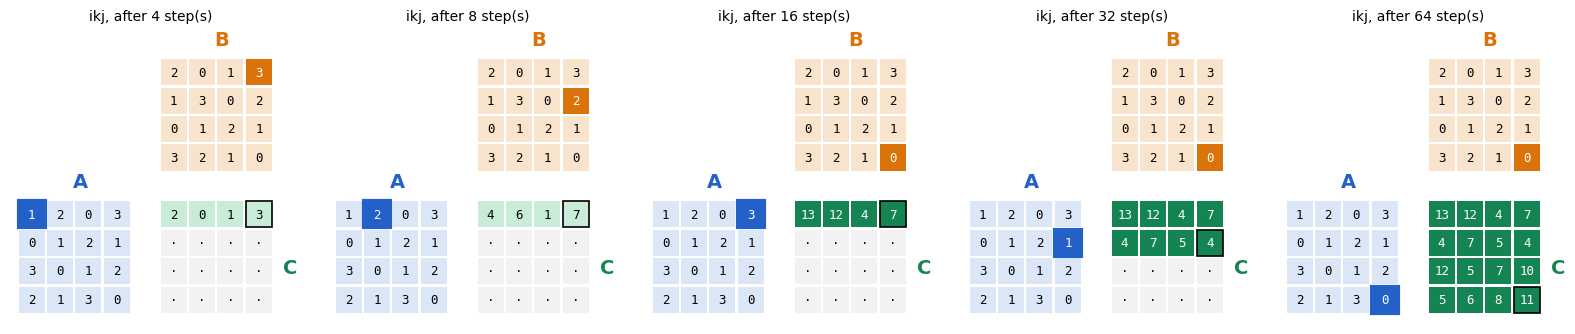

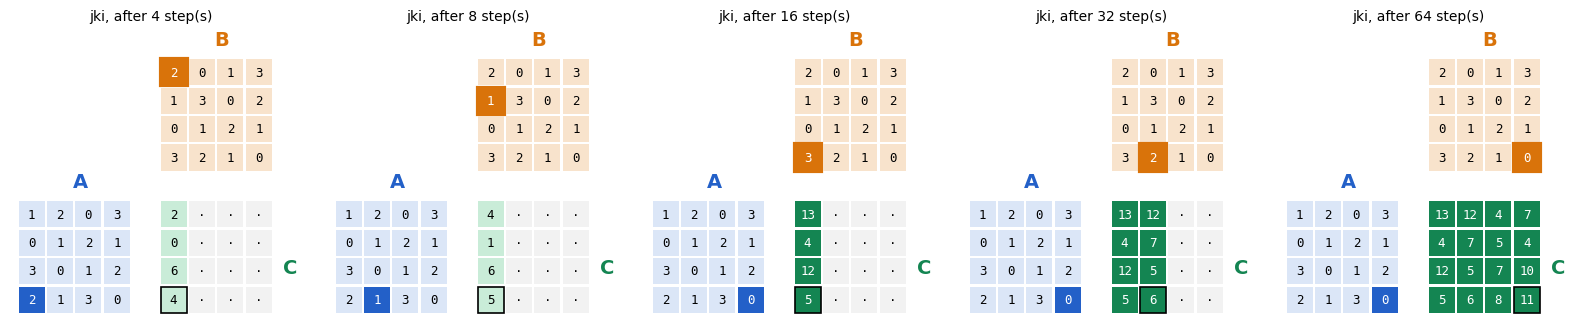

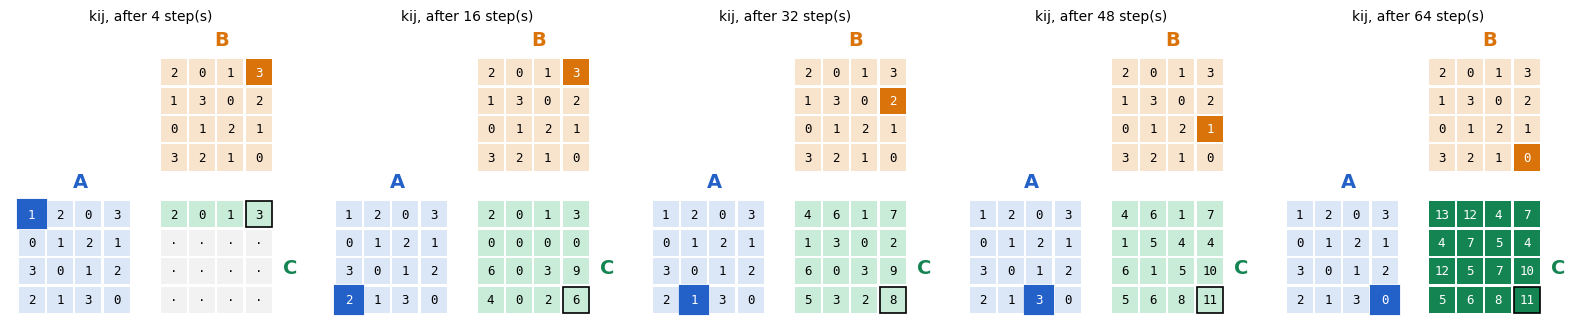

In [11]:
snapshots('ikj', [4, 8, 16, 32, 64])
snapshots('jki', [4, 8, 16, 32, 64])
snapshots('kij', [4, 16, 32, 48, 64])

## 4 · Partial sums: accumulating over time
In the inner-product form a <span style="color:#148552;font-weight:600">C</span> value is finished in one go. In the other forms a <span style="color:#148552;font-weight:600">C</span> value gets **one** of its 4 terms per visit and stays pale until its last term arrives. The unfinished value has to be kept somewhere between visits.

It stays in **one place**, and gets added to at **many different moments**. That is what "**accumulating over time**" means.

In [12]:
def after(order, t):
    tr = Tracker()
    x, y, z = order
    count = 0
    for a in range(4):
        for b in range(4):
            for c in range(4):
                if count == t:
                    return tr
                idx = {x: a, y: b, z: c}
                tr.step(idx["i"], idx["j"], idx["k"])
                count += 1
    return tr

for order in ["ijk", "kij"]:
    tr = after(order, 16)
    tr.picture(f"{order} after 16 of 64 steps: finished = {tr.finished()}, partial = {tr.partial()}")

print("\nMost values that are partial at the same moment (they all need a storage slot):")
for order in ["ijk", "jik", "ikj", "jki", "kij", "kji"]:
    worst = max(after(order, t).partial() for t in range(65))
    print(f"  {order}: {worst:2d}")

ijk after 16 of 64 steps: finished = 4, partial = 0   (* finished, ~ partial, . empty)
     13*  12*   4*   7*
       .    .    .    .
       .    .    .    .
       .    .    .    .
kij after 16 of 64 steps: finished = 0, partial = 16   (* finished, ~ partial, . empty)
      2~   0~   1~   3~
      0~   0~   0~   0~
      6~   0~   3~   9~
      4~   0~   2~   6~

Most values that are partial at the same moment (they all need a storage slot):
  ijk:  1
  jik:  1
  ikj:  4
  jki:  4
  kij: 16
  kji: 16


## 5 · Tiling: the same thing, in chunks
Cut each 4×4 matrix into four 2×2 blocks. Now call each block one "number" and each `*` one small matrix product. The block indices are **mt**, **nt**, **kt** (each 0 or 1), so the block grid is 2 × 2 × 2 = 8 block products.

In [13]:
def blk(X, r, c):
    return [row[2*c:2*c + 2] for row in X[2*r:2*r + 2]]

tr = Tracker()
for mt in range(2):
    for nt in range(2):
        for kt in range(2):
            for i in range(2):          # the small block product: 8 scalar multiplies
                for j in range(2):
                    for k in range(2):
                        tr.step(2*mt + i, 2*nt + j, 2*kt + k)
            print(f"C[{mt},{nt}] += A[{mt},{kt}] @ B[{kt},{nt}]   A-block {blk(A, mt, kt)}  B-block {blk(B, kt, nt)}"
                  f"   -> multiplies so far {tr.mults}")
tr.picture()
tr.check()

C[0,0] += A[0,0] @ B[0,0]   A-block [[1, 2], [0, 1]]  B-block [[2, 0], [1, 3]]   -> multiplies so far 8
C[0,0] += A[0,1] @ B[1,0]   A-block [[0, 3], [2, 1]]  B-block [[0, 1], [3, 2]]   -> multiplies so far 16
C[0,1] += A[0,0] @ B[0,1]   A-block [[1, 2], [0, 1]]  B-block [[1, 3], [0, 2]]   -> multiplies so far 24
C[0,1] += A[0,1] @ B[1,1]   A-block [[0, 3], [2, 1]]  B-block [[2, 1], [1, 0]]   -> multiplies so far 32
C[1,0] += A[1,0] @ B[0,0]   A-block [[3, 0], [2, 1]]  B-block [[2, 0], [1, 3]]   -> multiplies so far 40
C[1,0] += A[1,1] @ B[1,0]   A-block [[1, 2], [3, 0]]  B-block [[0, 1], [3, 2]]   -> multiplies so far 48
C[1,1] += A[1,0] @ B[0,1]   A-block [[3, 0], [2, 1]]  B-block [[1, 3], [0, 2]]   -> multiplies so far 56
C[1,1] += A[1,1] @ B[1,1]   A-block [[1, 2], [3, 0]]  B-block [[2, 1], [1, 0]]   -> multiplies so far 64
C   (* finished, ~ partial, . empty)
     13*  12*   4*   7*
      4*   7*   5*   4*
     12*   5*   7*  10*
      5*   6*   8*  11*
multiplies = 64, additions =

True

The six loop orders and the rule work unchanged on blocks: innermost kt → the C block stays put (os); innermost mt → the B block stays put (ws); innermost nt → the A block stays put (is).

Open up one block product, `C[0,0] += A[0,1] @ B[1,0]`. It is 8 ordinary multiplies. C already holds `A[0,0] @ B[0,0]` (pale), so these 8 steps finish the block.

In [14]:
tr = Tracker()
for i in range(2):                       # the first block product, already done
    for j in range(2):
        for k in range(2):
            tr.step(i, j, k)
print("block C[0,0] += A[0,1] @ B[1,0], as 8 scalar steps:")
for i in range(2):
    for j in range(2):
        for k in (2, 3):
            tr.step(i, j, k, say=True)

block C[0,0] += A[0,1] @ B[1,0], as 8 scalar steps:
step  9: C[0][0] += A[0][2]*B[2][0] = 0*0 = 0  ->  C[0][0] = 4 + 0 = 4   (term 3/4, partial)
step 10: C[0][0] += A[0][3]*B[3][0] = 3*3 = 9  ->  C[0][0] = 4 + 9 = 13   (term 4/4, FINISHED)
step 11: C[0][1] += A[0][2]*B[2][1] = 0*1 = 0  ->  C[0][1] = 6 + 0 = 6   (term 3/4, partial)
step 12: C[0][1] += A[0][3]*B[3][1] = 3*2 = 6  ->  C[0][1] = 6 + 6 = 12   (term 4/4, FINISHED)
step 13: C[1][0] += A[1][2]*B[2][0] = 2*0 = 0  ->  C[1][0] = 1 + 0 = 1   (term 3/4, partial)
step 14: C[1][0] += A[1][3]*B[3][0] = 1*3 = 3  ->  C[1][0] = 1 + 3 = 4   (term 4/4, FINISHED)
step 15: C[1][1] += A[1][2]*B[2][1] = 2*1 = 2  ->  C[1][1] = 3 + 2 = 5   (term 3/4, partial)
step 16: C[1][1] += A[1][3]*B[3][1] = 1*2 = 2  ->  C[1][1] = 5 + 2 = 7   (term 4/4, FINISHED)


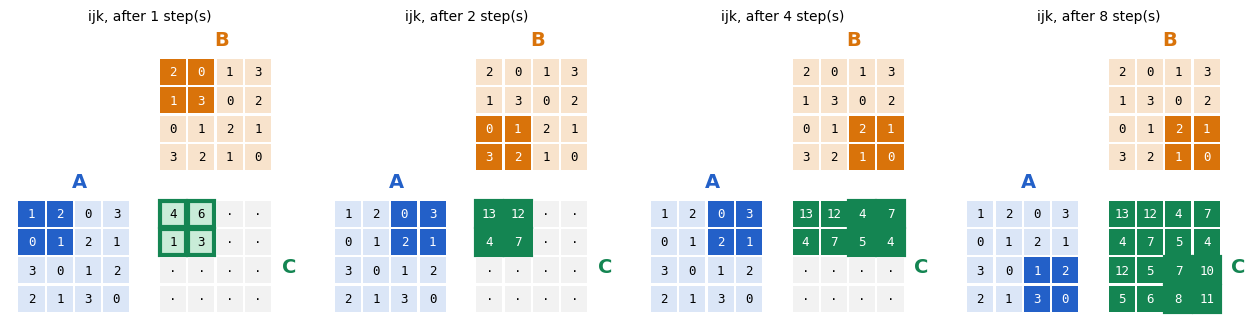

In [15]:
snapshots('ijk', [1, 2, 4, 8], bs=2)

## 6 · How big is "one step" in hardware?
The loops stay the same. What changes is how many of them the hardware does at once.

- **CPU core, scalar × scalar**: one multiply per step.
- **In-memory-compute array, vector × matrix**: a block of <span style="color:#d9730a;font-weight:600">B</span> is stored *inside* the memory cells. A row of <span style="color:#2360c8;font-weight:600">A</span> goes in, a row of <span style="color:#148552;font-weight:600">C</span> comes out. <span style="color:#d9730a;font-weight:600">B</span> never moves, so this hardware is naturally **weight-stationary**.
- **GPU tensor core, matrix × matrix**: a block of <span style="color:#2360c8;font-weight:600">A</span> times a block of <span style="color:#d9730a;font-weight:600">B</span> per step.

In [16]:
print("CPU: one multiply per step ->", M * N * K, "steps for the 4x4 product")

def imc_step(x_row, W):
    """W is stored in the array and does not move. One row goes in, one row comes out."""
    return [sum(x_row[k] * W[k][j] for k in range(len(W))) for j in range(len(W[0]))]

print("\nIn-memory array holding all of B (4x4 tiny version):")
for i in range(M):
    out = imc_step(A[i], B)
    print(f"  step {i}: in A[{i},:] = {A[i]}  ->  out C[{i},:] = {out}   (16 multiplies at once)")

print("\nTensor core (tiny: 2x2 @ 2x2 = 8 multiplies per step):", (M // 2) * (N // 2) * (K // 2), "steps")
print("Real sizes: IMC block 512 x 512 = 262,144 multiplies per step; WMMA 16x16x16 = 4,096.")

CPU: one multiply per step -> 64 steps for the 4x4 product

In-memory array holding all of B (4x4 tiny version):
  step 0: in A[0,:] = [1, 2, 0, 3]  ->  out C[0,:] = [13, 12, 4, 7]   (16 multiplies at once)
  step 1: in A[1,:] = [0, 1, 2, 1]  ->  out C[1,:] = [4, 7, 5, 4]   (16 multiplies at once)
  step 2: in A[2,:] = [3, 0, 1, 2]  ->  out C[2,:] = [12, 5, 7, 10]   (16 multiplies at once)
  step 3: in A[3,:] = [2, 1, 3, 0]  ->  out C[3,:] = [5, 6, 8, 11]   (16 multiplies at once)

Tensor core (tiny: 2x2 @ 2x2 = 8 multiplies per step): 8 steps
Real sizes: IMC block 512 x 512 = 262,144 multiplies per step; WMMA 16x16x16 = 4,096.


## 7 · Several cores
Now give the block loops to 4 cores. Press **Step** and watch: two of the three block loops are shared out so that all 4 cores work at the same time, and the third runs in order inside each core.

In [17]:
MODES = {"os": ("mt nt", "kt"), "ws": ("kt nt", "mt"), "is": ("mt kt", "nt")}
for mode, (grid, sweep) in MODES.items():
    g0, g1 = grid.split()
    print(f"{mode}: grid = {g0} x {g1} -> 4 cores, sweep = {sweep}")
    parts = {}                                   # (core, C block) -> partial block
    for t in range(2):
        line = []
        for core, (a, b) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
            idx = {g0: a, g1: b, sweep: t}
            mt, nt, kt = idx["mt"], idx["nt"], idx["kt"]
            line.append(f"core{core}: A{mt}{kt}@B{kt}{nt}->C{mt}{nt}")
            parts.setdefault(("C", mt, nt), set()).add(core)
        print(f"   time {t}: " + " | ".join(line))
    spread = max(len(cores) for cores in parts.values())
    if spread == 1:
        print("   every C block was built on ONE core: sum over time, no additions across cores\n")
    else:
        print(f"   every C block has pieces on {spread} cores: 16 extra additions ACROSS cores\n")

os: grid = mt x nt -> 4 cores, sweep = kt
   time 0: core0: A00@B00->C00 | core1: A00@B01->C01 | core2: A10@B00->C10 | core3: A10@B01->C11
   time 1: core0: A01@B10->C00 | core1: A01@B11->C01 | core2: A11@B10->C10 | core3: A11@B11->C11
   every C block was built on ONE core: sum over time, no additions across cores

ws: grid = kt x nt -> 4 cores, sweep = mt
   time 0: core0: A00@B00->C00 | core1: A00@B01->C01 | core2: A01@B10->C00 | core3: A01@B11->C01
   time 1: core0: A10@B00->C10 | core1: A10@B01->C11 | core2: A11@B10->C10 | core3: A11@B11->C11
   every C block has pieces on 2 cores: 16 extra additions ACROSS cores

is: grid = mt x kt -> 4 cores, sweep = nt
   time 0: core0: A00@B00->C00 | core1: A01@B10->C00 | core2: A10@B00->C10 | core3: A11@B10->C10
   time 1: core0: A00@B01->C01 | core1: A01@B11->C01 | core2: A10@B01->C11 | core3: A11@B11->C11
   every C block has pieces on 2 cores: 16 extra additions ACROSS cores



The loops shared out over the cores and run at the same time form the **tile grid**. The loop that runs in order on each core is the **sweep**.

- os: grid = mt × nt (each core owns a <span style="color:#148552;font-weight:600">C</span> block), sweep over kt
- ws: grid = kt × nt (each core keeps a <span style="color:#d9730a;font-weight:600">B</span> block), sweep over mt
- is: grid = mt × kt (each core keeps an <span style="color:#2360c8;font-weight:600">A</span> block), sweep over nt

When there are more tiles than cores, the cores take them in **waves**. 8 tiles on 4 cores is 2 full waves. 8 tiles on 3 cores is 3 waves, and in the last one a core has nothing to do.

In [18]:
import math
def waves(tiles, cores):
    w = math.ceil(tiles / cores)
    idle = w * cores - tiles
    print(f"{tiles} tiles on {cores} cores: {w} waves, last wave {tiles - (w - 1) * cores}/{cores} busy, "
          f"{idle} idle core-slots, utilisation {100 * tiles / (w * cores):.0f}%")
for c in (2, 3, 4, 5, 8):
    waves(8, c)

8 tiles on 2 cores: 4 waves, last wave 2/2 busy, 0 idle core-slots, utilisation 100%
8 tiles on 3 cores: 3 waves, last wave 2/3 busy, 1 idle core-slots, utilisation 89%
8 tiles on 4 cores: 2 waves, last wave 4/4 busy, 0 idle core-slots, utilisation 100%
8 tiles on 5 cores: 2 waves, last wave 3/5 busy, 2 idle core-slots, utilisation 80%
8 tiles on 8 cores: 1 waves, last wave 8/8 busy, 0 idle core-slots, utilisation 100%


## 8 · Accumulating over space
In ws and is, k is on the grid, so the pieces of one <span style="color:#148552;font-weight:600">C</span> block are made on **different cores**. Someone has to add them together afterwards: an extra step, with data moving between cores. These additions happen in **space** (across places), drawn in <span style="color:#a8329a;font-weight:600">magenta</span>.

The total number of additions never changes (48). What changes is **where** they happen:
- all K terms of an output on one core (or in one array column): every addition is over time, free of traffic
- **K-groups**: g cores share an output, each adds its own group over time, then only g partial sums are added across cores
- every k on its own core: every addition is across cores

In [19]:
i, j = 0, 0
terms = [A[i][k] * B[k][j] for k in range(K)]
print(f"C[{i}][{j}] = sum of {terms} = {sum(terms)}")
for g in (1, 2, 4):
    per = K // g
    groups = [terms[c * per:(c + 1) * per] for c in range(g)]
    local = [sum(x) for x in groups]
    print(f"g = {g}: cores hold {groups} -> local sums {local} "
          f"({g * (per - 1)} additions over time), then {g - 1} addition(s) across cores -> {sum(local)}")
print("\nWhole 4x4 product (16 outputs):")
for g in (1, 2, 4):
    per = K // g
    print(f"  g = {g}: over time {16 * g * (per - 1):2d}, across cores {16 * (g - 1):2d}, total {16 * g * (per - 1) + 16 * (g - 1)}")

C[0][0] = sum of [2, 2, 0, 9] = 13
g = 1: cores hold [[2, 2, 0, 9]] -> local sums [13] (3 additions over time), then 0 addition(s) across cores -> 13
g = 2: cores hold [[2, 2], [0, 9]] -> local sums [4, 9] (2 additions over time), then 1 addition(s) across cores -> 13
g = 4: cores hold [[2], [2], [0], [9]] -> local sums [2, 2, 0, 9] (0 additions over time), then 3 addition(s) across cores -> 13

Whole 4x4 product (16 outputs):
  g = 1: over time 48, across cores  0, total 48
  g = 2: over time 32, across cores 16, total 48
  g = 4: over time  0, across cores 48, total 48


**Split-K**: cut K into pieces, give each piece to a core, let each core compute a *whole* output from its piece, then add the pieces at the end.

In [20]:
pieces = [(0, 1), (2, 3)]
Cs = []
for p, ks in enumerate(pieces):
    tr = Tracker()
    for k in ks:
        for i in range(M):
            for j in range(N):
                tr.step(i, j, k)
    show(f"C_piece{p} (k in {ks}, on core {p}, {tr.adds} additions over time)", tr.C)
    Cs.append(tr.C)
C = [[Cs[0][i][j] + Cs[1][i][j] for j in range(N)] for i in range(M)]
show("C = C_piece0 + C_piece1   (16 additions across cores)", C)
print("C == A @ B ?", C == REF)

C_piece0 (k in (0, 1), on core 0, 16 additions over time) =
      4   6   1   7
      1   3   0   2
      6   0   3   9
      5   3   2   8
C_piece1 (k in (2, 3), on core 1, 16 additions over time) =
      9   6   3   0
      3   4   5   2
      6   5   4   1
      0   3   6   3
C = C_piece0 + C_piece1   (16 additions across cores) =
     13  12   4   7
      4   7   5   4
     12   5   7  10
      5   6   8  11
C == A @ B ? True


## 9 · Cheat sheet

| loop order | classic name | stays put | one inner loop produces | finished or partial | where the K-sum happens |
|---|---|---|---|---|---|
| ijk, jik | inner product | <span style="color:#148552;font-weight:600">C</span>[i][j] (os) | one scalar <span style="color:#148552;font-weight:600">C</span>[i][j] | finished | time, in one register |
| ikj | row-wise (Gustavson) | <span style="color:#2360c8;font-weight:600">A</span>[i][k] (is) | a scaled row of <span style="color:#d9730a;font-weight:600">B</span> added into row i of <span style="color:#148552;font-weight:600">C</span> | partial until the last k for that row | time, in a row of <span style="color:#148552;font-weight:600">C</span> |
| jki | column-wise | <span style="color:#d9730a;font-weight:600">B</span>[k][j] (ws) | a scaled column of <span style="color:#2360c8;font-weight:600">A</span> added into column j of <span style="color:#148552;font-weight:600">C</span> | partial until the last k for that column | time, in a column of <span style="color:#148552;font-weight:600">C</span> |
| kij | outer product | <span style="color:#2360c8;font-weight:600">A</span>[i][k] (is) | one row of a rank-1 update; the two inner loops: a whole-matrix update | partial until the last k | time, in all of <span style="color:#148552;font-weight:600">C</span> |
| kji | outer product | <span style="color:#d9730a;font-weight:600">B</span>[k][j] (ws) | one column of a rank-1 update; the two inner loops: a whole-matrix update | partial until the last k | time, in all of <span style="color:#148552;font-weight:600">C</span> |
| tiled, any order | same names, per block | a block | a block product (8 multiplies here) | same as its scalar order | same as its scalar order |
| os grid | M×N tiles | <span style="color:#148552;font-weight:600">C</span> block per core | whole output tiles | finished on its core | time |
| ws / is grid | K on the grid | <span style="color:#d9730a;font-weight:600">B</span> or <span style="color:#2360c8;font-weight:600">A</span> block per core | pieces of <span style="color:#148552;font-weight:600">C</span> blocks | partial until combined | <span style="color:#a8329a;font-weight:600">space</span> (across cores) |
| split-K | K cut into pieces | depends on inner order | a whole partial <span style="color:#148552;font-weight:600">C</span> per piece | partial until combined | time inside a piece, <span style="color:#a8329a;font-weight:600">space</span> between pieces |

Every row: 64 multiplies and 48 additions on the 4×4 example.

In [21]:
for order in ["ijk", "jik", "ikj", "kij", "jki", "kji"]:
    tr = run(order)
    assert tr.mults == 64 and tr.adds == 48 and tr.C == REF
print("All six loop orders: 64 multiplies, 48 additions, C == A @ B.")
show("C", REF)

All six loop orders: 64 multiplies, 48 additions, C == A @ B.
C =
     13  12   4   7
      4   7   5   4
     12   5   7  10
      5   6   8  11
